In [2]:
from torchvision.io import decode_image
from torchvision.models import get_model, get_model_weights
from torchcam.methods import LayerCAM

weights = get_model_weights("resnet18").DEFAULT
model = get_model("resnet18", weights=weights).eval()

preprocess = weights.transforms()

img_1 = decode_image("data/Rottweiler_Dog.jpg")

input_tensor = preprocess(img_1)

with LayerCAM(model) as cam_extractor:
    out = model(input_tensor.unsqueeze(0))
    activation_map = cam_extractor(out.squeeze(0).argmax().item(), out)
    


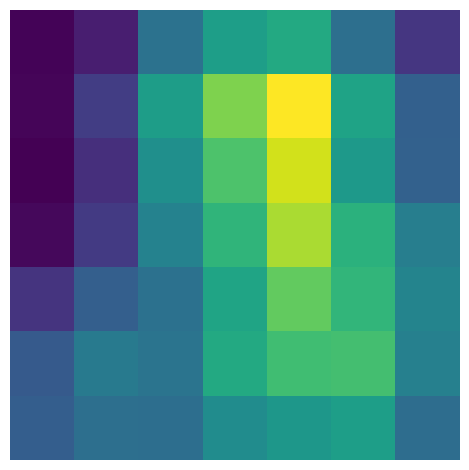

In [3]:
import matplotlib.pyplot as plt

plt.imshow(activation_map[0].squeeze(0).numpy())
plt.axis("off")
plt.tight_layout()
plt.show()

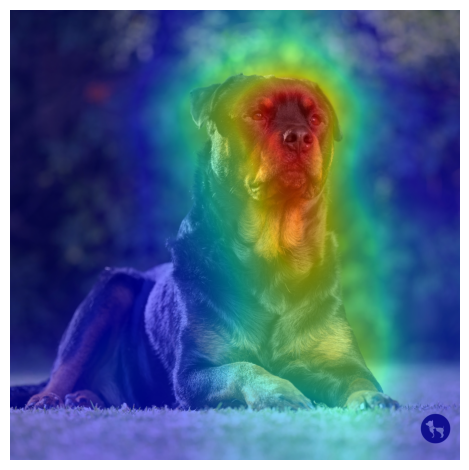

In [4]:
from torchvision.transforms.v2.functional import to_pil_image
from torchcam.utils import overlay_mask

result = overlay_mask(to_pil_image(img_1), to_pil_image(activation_map[0].squeeze(0), mode="F"), alpha=0.5)

plt.imshow(result)
plt.axis("off")
plt.tight_layout()
plt.show()

In [5]:
#> claude.ai
#> I have a json file with class names (imagenet_class_index.json) from 1000 classes in ImageNet and an output
# tensor from a ResNet18 (with default pretrained weights) softmax operation.
# Give a function that maps the maximum logit in the output tensor to the class name from the json file.

import json
import torch

def predict_class(output_tensor: torch.Tensor, class_index_path: str) -> dict:
    """
    Maps the maimum logit in a softmax output tensor to an ImageNet class name.
    
    Args:
        output_tensor:  1D or 2D tensor of shape (1000,) or (1, 1000),
                        typically the output of a softmax layer from ResNet18.
        
        class_index_path: Path to the imagenet_class_index.json file.
        
    Returns:
        A dict with keys:
            - 'class_index' (int)   : index of the preducted class (0-999)
            - 'class_id'    (str)   : WordNet synset ID, e.g. "n01140764"
            - 'class_name'  (str)   : human-readable label, e.g. "tench"
            - 'confidence'  (float) : softmax probability of the top class
            """
    
    with open(class_index_path, "r") as f:
        class_index = json.load(f)  # keys are str "0".."999"

        # Flatten to 1-D in case the tensor has a betch dimension
        probs = output_tensor.squeeze()     #(1000,)
        if probs.ndim != 1 or probs.shape[0] != 1000:
            raise ValueError(
                f"Expected a tensor of 1000 values, got shape {tuple(output_tensor.shape)}"
            )
        
        top_idx = int(probs.argmax())           # index of highest probability
        synset_id, class_name = class_index[str(top_idx)]

        return {
            "class_index":  top_idx,
            "class_id":     synset_id,
            "class_name":   class_name,
            "confidence":   float(probs[top_idx])
        }

In [6]:
model.eval()
batch = preprocess(img_1).unsqueeze(0)
prediction = model(batch).squeeze(0).softmax(0)

In [7]:
predict_class(prediction.detach(), "data/imagenet_class_index.json")

{'class_index': 234,
 'class_id': 'n02106550',
 'class_name': 'Rottweiler',
 'confidence': 0.9174423813819885}

In [8]:
img_2 = decode_image("data/Red_Kangaroo.jpg")

input_tensor = preprocess(img_2)

with LayerCAM(model) as cam_extractor:
    out = model(input_tensor.unsqueeze(0))
    activation_map = cam_extractor(out.squeeze(0).argmax().item(), out)
    

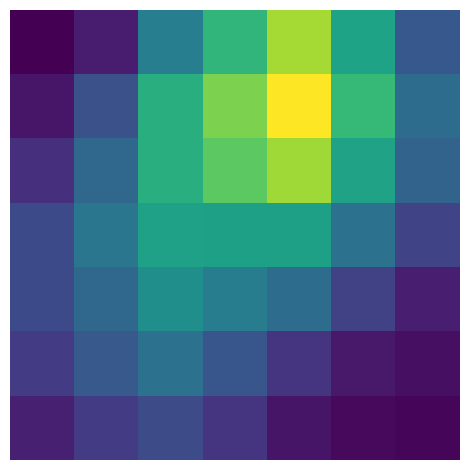

In [9]:
plt.imshow(activation_map[0].squeeze(0).numpy())
plt.axis("off")
plt.tight_layout() 
plt.show()

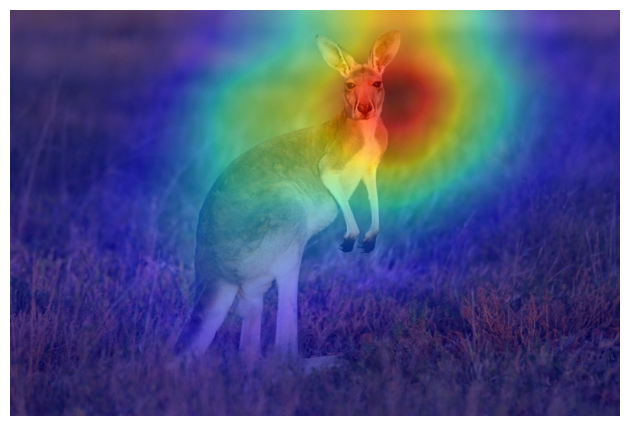

In [10]:
result = overlay_mask(to_pil_image(img_2), to_pil_image(activation_map[0].squeeze(0), mode="F"), alpha=0.5)

plt.imshow(result)
plt.axis("off")
plt.tight_layout()
plt.show()

In [11]:
model.eval()
batch = preprocess(img_2.unsqueeze(0))
prediction = model(batch).squeeze(0).softmax(0)
predict_class(prediction.detach(), "data/imagenet_class_index.json")

{'class_index': 331,
 'class_id': 'n02326432',
 'class_name': 'hare',
 'confidence': 0.8053424954414368}

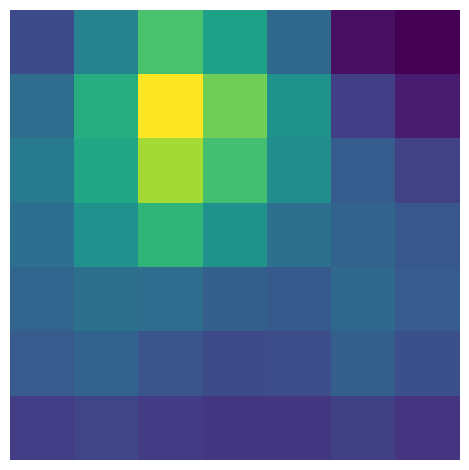

In [12]:
img_3 = decode_image("data/horse.jpg")

input_tensor = preprocess(img_3)

with LayerCAM(model) as cam_extractor:
    out = model(input_tensor.unsqueeze(0))
    activation_map = cam_extractor(out.squeeze(0).argmax().item(), out)

plt.imshow(activation_map[0].squeeze(0).numpy())
plt.axis("off")
plt.tight_layout()
plt.show()

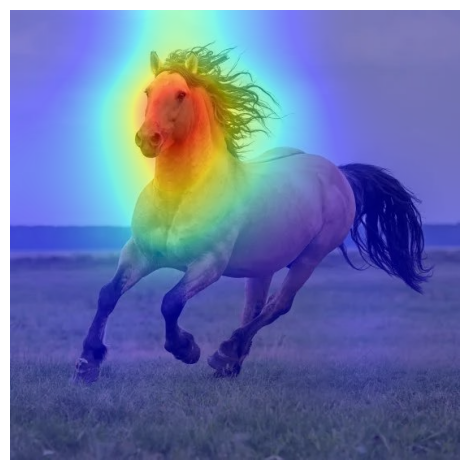

In [13]:
result = overlay_mask(to_pil_image(img_3), to_pil_image(activation_map[0].squeeze(0), mode="F"), alpha=0.5)

plt.imshow(result)
plt.axis("off")
plt.tight_layout()
plt.show()

In [14]:
model.eval()
batch = preprocess(img_3.unsqueeze(0))
prediction = model(batch).squeeze(0).softmax(0)
predict_class(prediction.detach(), "data/imagenet_class_index.json")

{'class_index': 176,
 'class_id': 'n02091831',
 'class_name': 'Saluki',
 'confidence': 0.5554572343826294}

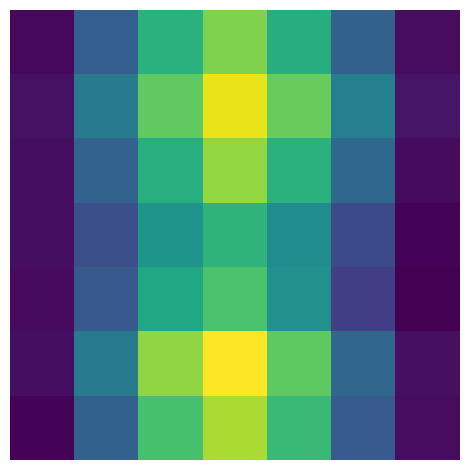

In [15]:
img_4 = decode_image("data/ipod.jpg")

input_tensor = preprocess(img_4)

with LayerCAM(model) as cam_extractor:
    out = model(input_tensor.unsqueeze(0))
    activation_map = cam_extractor(out.squeeze(0).argmax().item(), out)

plt.imshow(activation_map[0].squeeze(0).numpy())
plt.axis("off")
plt.tight_layout()
plt.show()

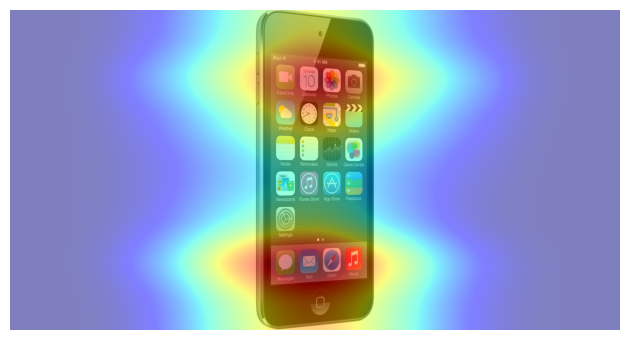

In [16]:
result = overlay_mask(to_pil_image(img_4), to_pil_image(activation_map[0].squeeze(0), mode="F"), alpha=0.5)

plt.imshow(result)
plt.axis("off")
plt.tight_layout()
plt.show()

In [17]:
model.eval()
batch = preprocess(img_4.unsqueeze(0))
prediction = model(batch).squeeze(0).softmax(0)
predict_class(prediction.detach(), "data/imagenet_class_index.json")

{'class_index': 487,
 'class_id': 'n02992529',
 'class_name': 'cellular_telephone',
 'confidence': 0.49566930532455444}

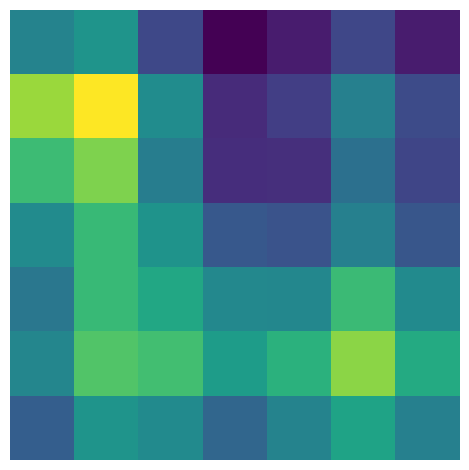

In [18]:
img_5 = decode_image("data/ohmu.jpg")

input_tensor = preprocess(img_5)

with LayerCAM(model) as cam_extractor:
    out = model(input_tensor.unsqueeze(0))
    activation_map = cam_extractor(out.squeeze(0).argmax().item(), out)

plt.imshow(activation_map[0].squeeze(0).numpy())
plt.axis("off")
plt.tight_layout()
plt.show()

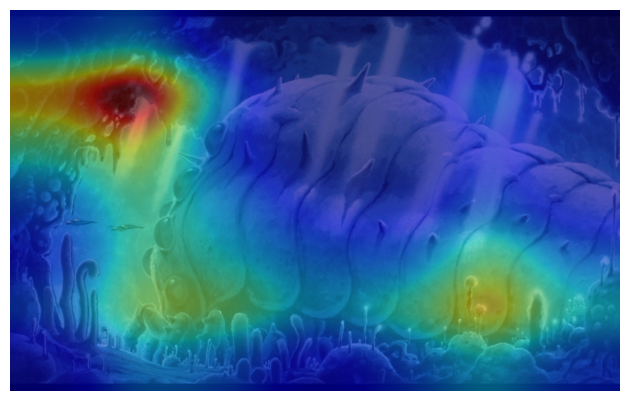

In [19]:
result = overlay_mask(to_pil_image(img_5), to_pil_image(activation_map[0].squeeze(0), mode="F"), alpha=0.5)

plt.imshow(result)
plt.axis("off")
plt.tight_layout()
plt.show()

In [20]:
model.eval()
batch = preprocess(img_5.unsqueeze(0))
prediction = model(batch).squeeze(0).softmax(0)
predict_class(prediction.detach(), "data/imagenet_class_index.json")

{'class_index': 126,
 'class_id': 'n01990800',
 'class_name': 'isopod',
 'confidence': 0.3133256137371063}